# MODELIZACIÓN

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

Cargar los datos.

In [2]:
x = pd.read_pickle("../02_datos/03_Entrenamiento/x_preseleccionado.pkl")
y = pd.read_pickle("../02_datos/03_Entrenamiento/y_preseleccionado.pkl")

## MODELIZANDO PARA UN PRODUCTO

In [3]:
x = x.loc[(x.store_id == 'CA_3') & (x.item_id == 'FOODS_3_586')]

In [4]:
y = y[y.index.isin(x.index)]

In [5]:
x.columns.to_list()

['date',
 'store_id',
 'item_id',
 'ventas_mm_8',
 'ventas_mm_7',
 'ventas_mm_6',
 'ventas_mm_9',
 'ventas_mm_2',
 'ventas_mm_10',
 'ventas_mm_3',
 'ventas_mm_5',
 'ventas_lag_1',
 'ventas_mm_15',
 'ventas_mm_11',
 'ventas_maxm_8',
 'ventas_mm_4',
 'ventas_maxm_7',
 'ventas_mm_12',
 'ventas_maxm_2',
 'ventas_mm_14',
 'ventas_maxm_6',
 'ventas_mm_13',
 'ventas_maxm_3',
 'ventas_maxm_9',
 'ventas_maxm_4',
 'ventas_maxm_5',
 'ventas_maxm_10',
 'ventas_minm_2',
 'ventas_maxm_11',
 'ventas_maxm_15',
 'ventas_maxm_12',
 'ventas_maxm_14',
 'ventas_maxm_13',
 'ventas_minm_3',
 'ventas_minm_4',
 'ventas_minm_5',
 'ventas_minm_6',
 'ventas_lag_2',
 'ventas_minm_7',
 'ventas_minm_8',
 'ventas_lag_7',
 'ventas_minm_9',
 'ventas_minm_10',
 'ventas_lag_6',
 'ventas_lag_3',
 'ventas_minm_12',
 'ventas_minm_11',
 'ventas_lag_8',
 'ventas_lag_5',
 'ventas_minm_13',
 'ventas_minm_14',
 'ventas_lag_4',
 'ventas_minm_15',
 'ventas_lag_14',
 'ventas_lag_13',
 'ventas_lag_9',
 'ventas_lag_15',
 'ventas_lag_

### MODELIZAR

#### Definir las variables de modelización

In [6]:
# Como estamos con modelo de product-tienda, quitamos las identificadoras (date,store_id, item_id)
var_modelizar = x.columns.to_list()[3:]

#### Definir la validacion

In [7]:
time_cv = TimeSeriesSplit(3, test_size = 8)

#### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

Modificar para dejar solo los algoritmos que se quieran testar.

Modificar los parámetros.

In [8]:
pipe = Pipeline([('algoritmo',HistGradientBoostingRegressor())])

grid = [
    {'algoritmo': [HistGradientBoostingRegressor()]
     #'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
     #'algoritmo__max_iter': [300,500,800],
     #'algoritmo__max_depth': [3,5,10]
     }
]

#### Optimizar los hiper parámetros

#####  Con random search

In [9]:
random_search = RandomizedSearchCV(estimator = pipe,
                                   param_distributions = grid, 
                                   n_iter = 1, 
                                   cv = time_cv, 
                                   scoring = 'neg_mean_absolute_error', 
                                   verbose = 0,
                                   n_jobs = -1)

modelo = random_search.fit(x[var_modelizar],y)

In [10]:
modelo_final = modelo.best_estimator_.fit(x[var_modelizar],y)

In [11]:
prediccion = modelo_final.predict(x[var_modelizar])

In [12]:
temp = pd.concat([x.date.reset_index(drop=True),y.reset_index(drop=True),pd.Series(prediccion,name = 'prediccion')],axis = 1).set_index('date')

In [13]:
temp

,ventas,prediccion
date,,
2013-01-16,6,6.855
2013-01-17,13,11.480
2013-01-18,8,9.731
2013-01-19,13,12.786
2013-01-20,13,11.456
...,...,...
2015-11-26,14,12.591
2015-11-27,10,9.973
2015-11-28,6,7.869


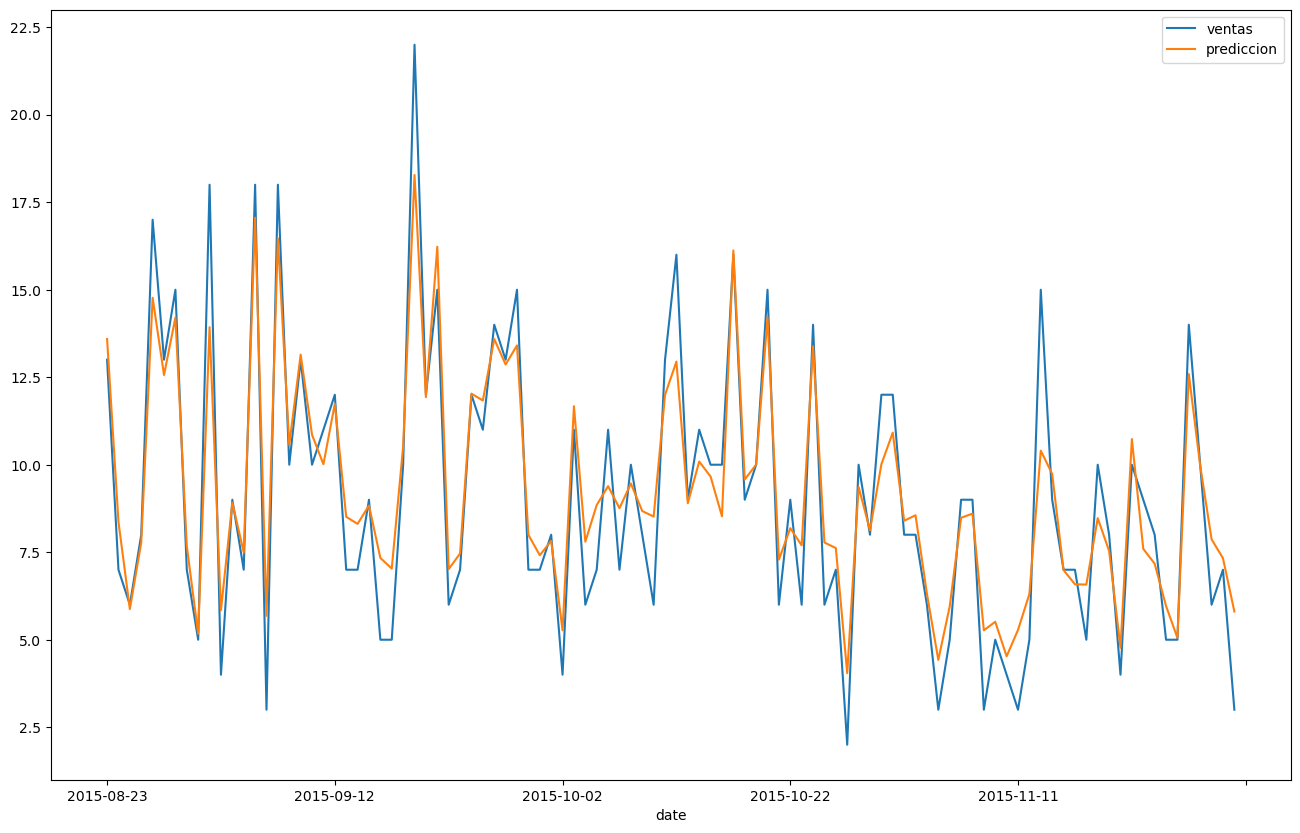

In [14]:
temp.tail(100).plot(figsize = (16,10));

## ESCALAR A TODOS LOS PRODUCTOS

### MODELIZACIÓN

Ya tenemos el proceso funcionando para modelizar un producto.

Ahora tenemos que escalarlo a todas las combinaciones de tiendas y productos.

Primero vamos a volver a importar los datos.

In [15]:
x = pd.read_pickle("../02_datos/03_Entrenamiento/x_preseleccionado.pkl")
y = pd.read_pickle("../02_datos/03_Entrenamiento/y_preseleccionado.pkl")

Incluímos como una nueva variable la combinación de tienda-producto y eliminamos las originales.

In [16]:
x.insert(loc=0,column='producto',value=x.store_id + '_'+ x.item_id)
x = x.drop(columns = ['store_id','item_id'])
x.head()

,producto,date,ventas_mm_8,ventas_mm_7,ventas_mm_6,ventas_mm_9,ventas_mm_2,ventas_mm_10,ventas_mm_3,ventas_mm_5,...,rotura_stock_7_lag_1,rotura_stock_15_lag_1,year_te,weekday_te,year_2015,event_name_1_Easter,month_te,wday_te,event_name_1_ColumbusDay,year_2013
0,CA_3_FOODS_3_090,2013-01-16,233.375,236.000,242.500,228.333,182.000,232.500,215.000,242.000,...,0.000,0.000,29.953,24.894,0.000,0.000,25.394,24.894,0.000,1.000
1,CA_3_FOODS_3_090,2013-01-17,230.375,235.143,233.500,228.667,174.500,224.600,185.000,237.400,...,0.000,0.000,29.953,26.096,0.000,0.000,25.394,26.096,0.000,1.000
2,CA_3_FOODS_3_090,2013-01-18,227.000,224.429,226.167,223.667,180.500,222.800,173.000,201.200,...,0.000,0.000,29.953,29.476,0.000,0.000,25.394,29.476,0.000,1.000
3,CA_3_FOODS_3_090,2013-01-19,224.375,225.857,205.000,226.667,197.000,223.700,195.000,189.800,...,0.000,0.000,29.953,34.801,0.000,0.000,25.394,34.801,0.000,1.000
4,CA_3_FOODS_3_090,2013-01-20,242.875,227.429,218.500,239.667,293.000,240.200,252.000,221.000,...,0.000,0.000,29.953,34.385,0.000,0.000,25.394,34.385,0.000,1.000


Para poder aplicar el proceso de forma recurrente vamos a crear una lista donde cada elemento sean los datos de cada producto.

In [17]:
productos = list(x.groupby("producto"))


Encapsulamos el proceso de modelización individual en una función, a la que iremos llamando en cada producto.

In [18]:
#Recibe los datos de las x y la y de cada producto

def modelizar(x_producto, y):
          
    #Excluye el producto como variable de modelización
    var_modelizar = x_producto.columns.to_list()[2:]
    
    #Define la validación cruzada
    time_cv = TimeSeriesSplit(3, test_size = 8)
    
    #Define la parrilla de algoritmos
    pipe = Pipeline([('algoritmo',HistGradientBoostingRegressor())])
    grid = [ 
         {'algoritmo': [HistGradientBoostingRegressor()]
#          'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
#          'algoritmo__max_iter': [50,100,200],
#          'algoritmo__max_depth': [5,10,20,50],
#          'algoritmo__scoring': ['neg_mean_absolute_error'],
#          'algoritmo__l2_regularization': [0,0.25,0.5,0.75,1]
         }
                       
    ]
           
    #Crea los modelos
    random_search = RandomizedSearchCV(estimator = pipe,
                                   param_distributions = grid, 
                                   n_iter = 1, 
                                   cv = time_cv, 
                                   scoring = 'neg_mean_absolute_error', 
                                   verbose = 0,
                                   n_jobs = -1)
    
    modelo = random_search.fit(x_producto[var_modelizar],y)
    
    #Reentrena el mejor sobre todos los datos
    modelo_final = modelo.best_estimator_.fit(x_producto[var_modelizar],y)
    
    #Devuelve como salida el modelo final
    return(modelo_final)

Creamos otra lista vacía donde vamos a ir guardando los modelos entrenados de cada producto.

In [19]:
lista_modelos = []

Recorremos cada elemento de la lista de productos y vamos rellendando lista_modelos con el nombre y modelo final de cada producto.

In [20]:
for cada in productos:
    #Renombra por claridad
    producto = cada[0]
    datos = cada[1]
    #Selecciona solo los datos de la target que se corresponden con el producto
    y_cada = y[y.index.isin(datos.index)]

    #Llama a la funcion de modelizar
    modelo = modelizar(datos,y_cada)
    #Añade el modelo final a la lista
    lista_modelos.append((producto,modelo))
    

In [21]:
lista_modelos

[('CA_3_FOODS_3_090',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_120',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_202',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_252',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_288',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_329',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_555',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_586',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_587',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_3_FOODS_3_714',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),
 ('CA_4_FOODS_3_090',
  Pipeline(steps=[('algoritmo', HistGradientBoostingRegressor())])),

Comprobamos.

NOTA: El objetivo aquí no es evaluar la calidad del modelo, ya que no estamos usando los datos de entrenamiento.

Es simplemente comprobar que el proceso funciona bien y no vemos nada raro antes de continuar.

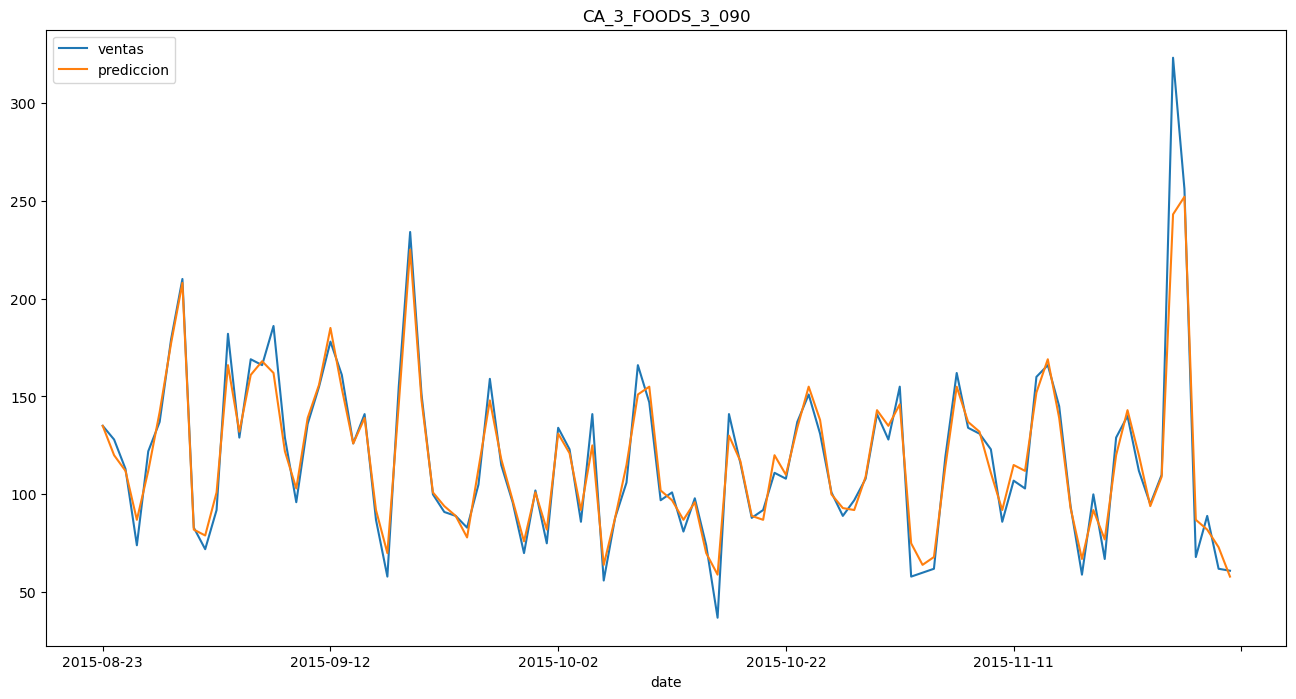

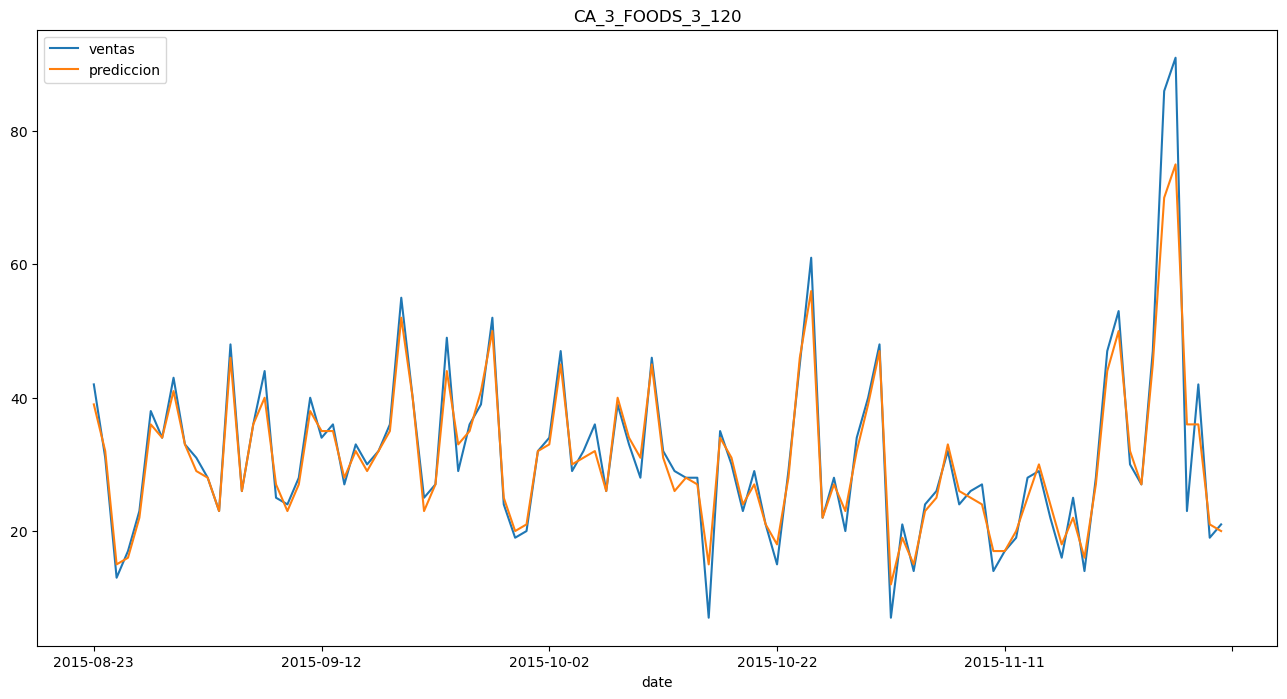

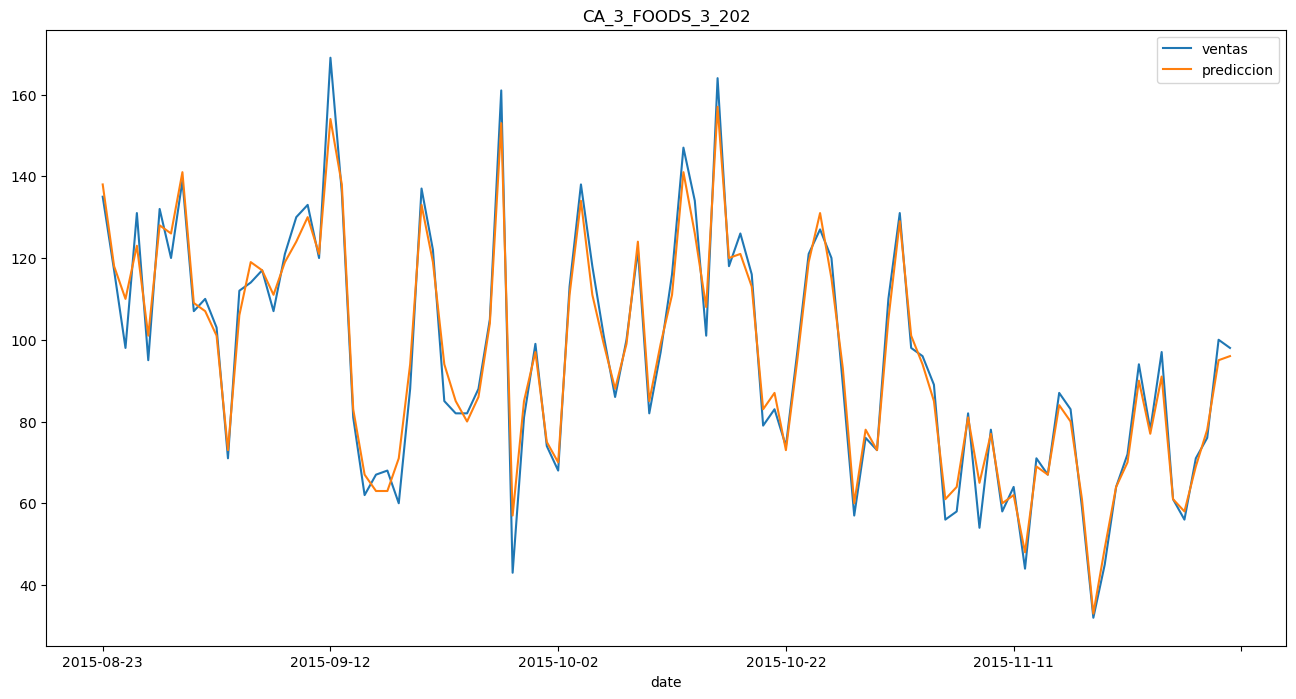

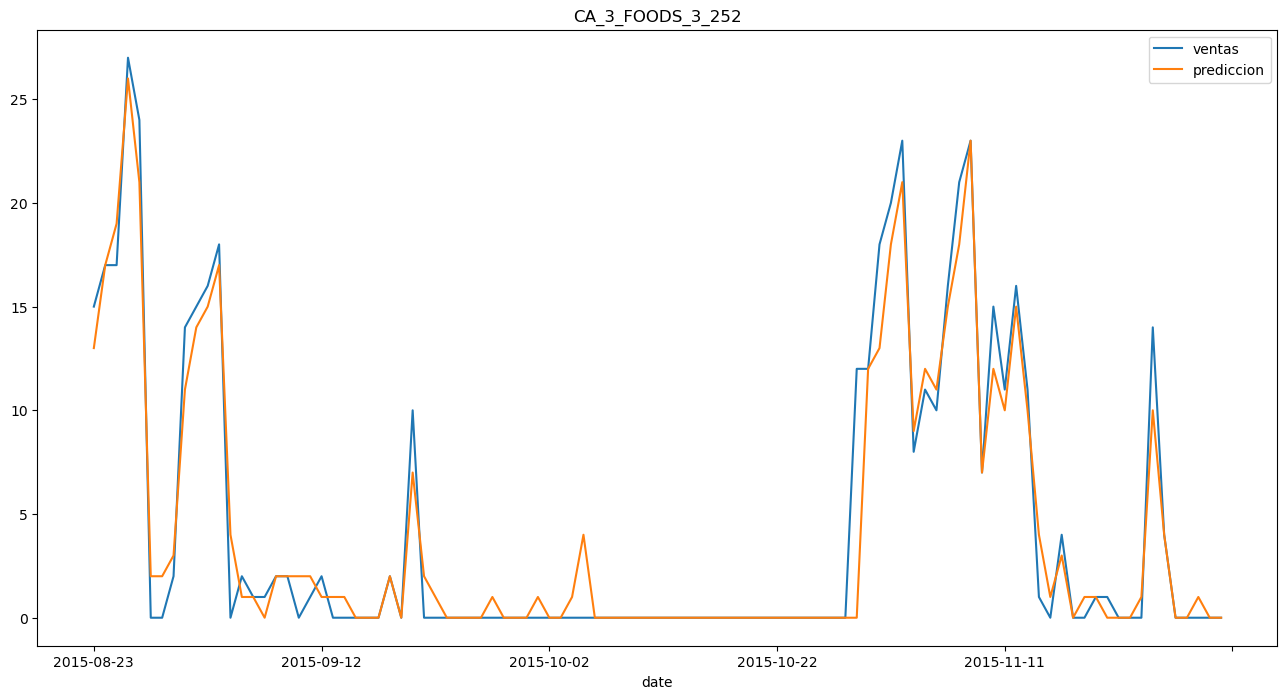

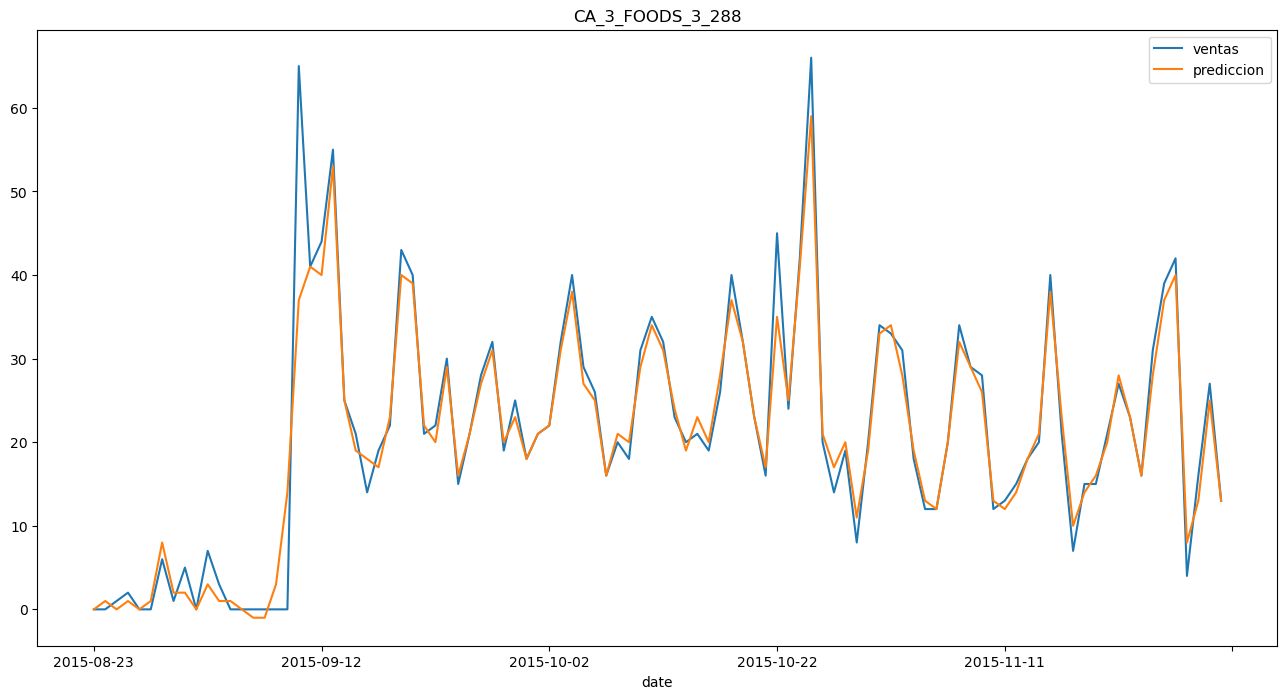

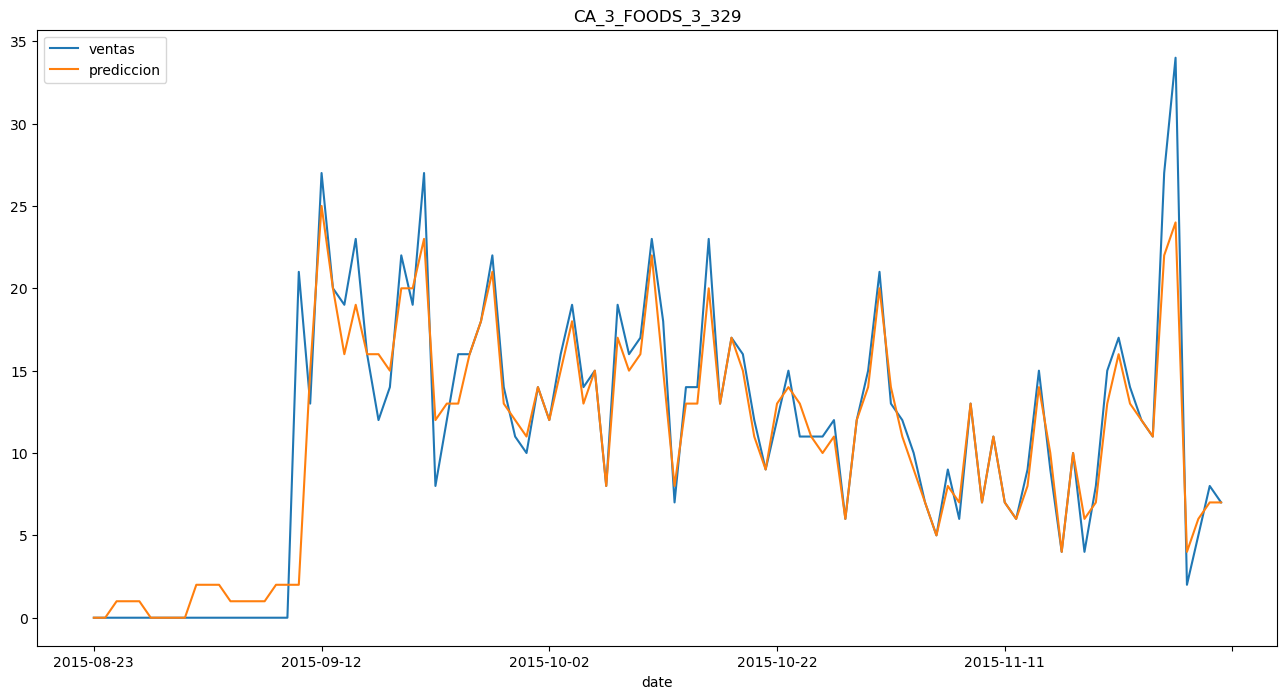

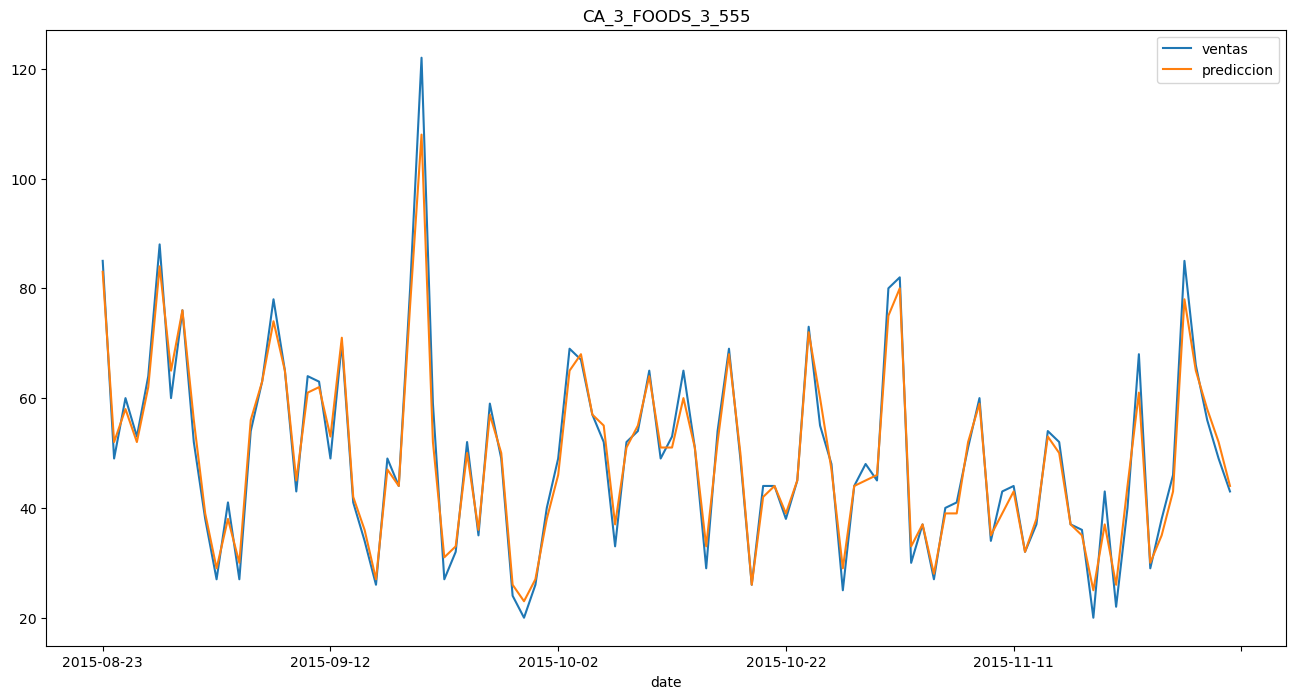

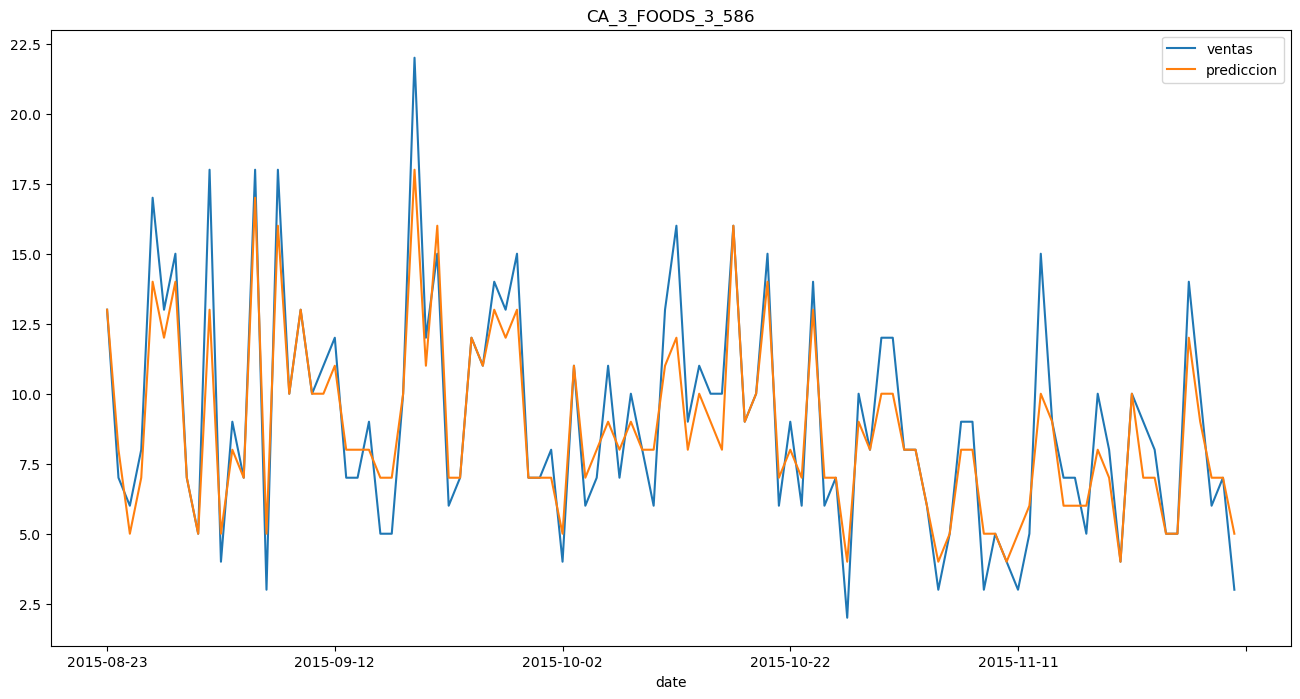

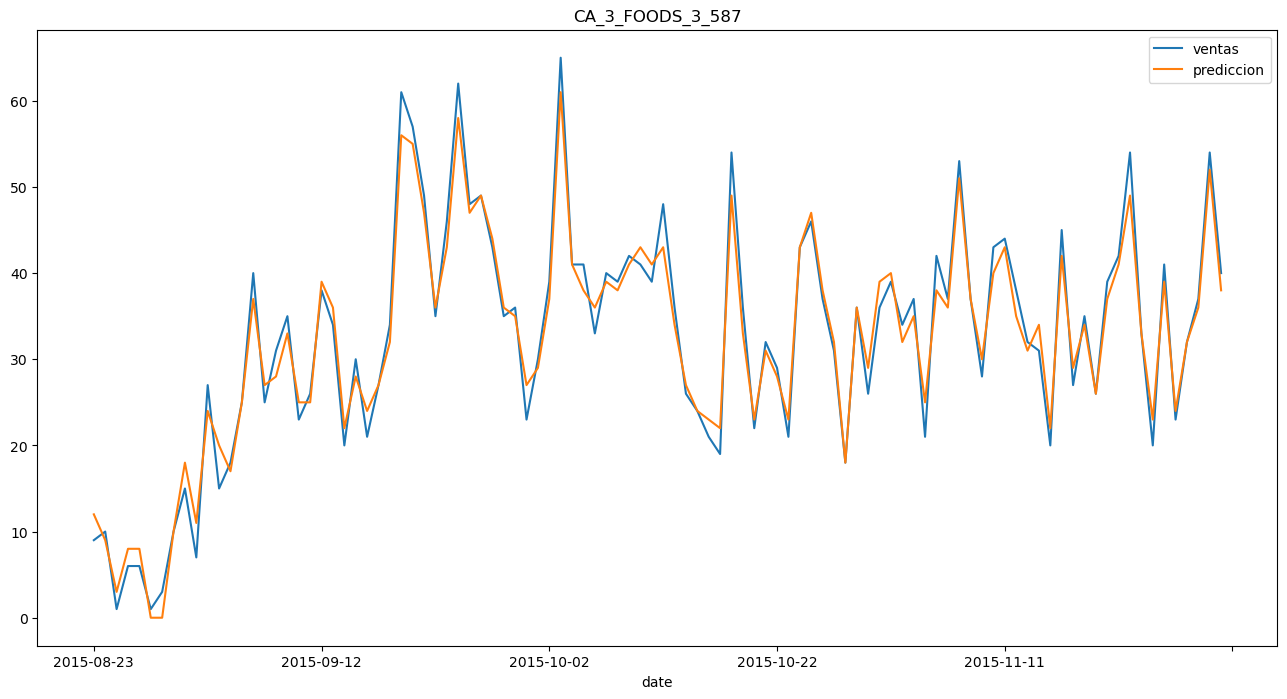

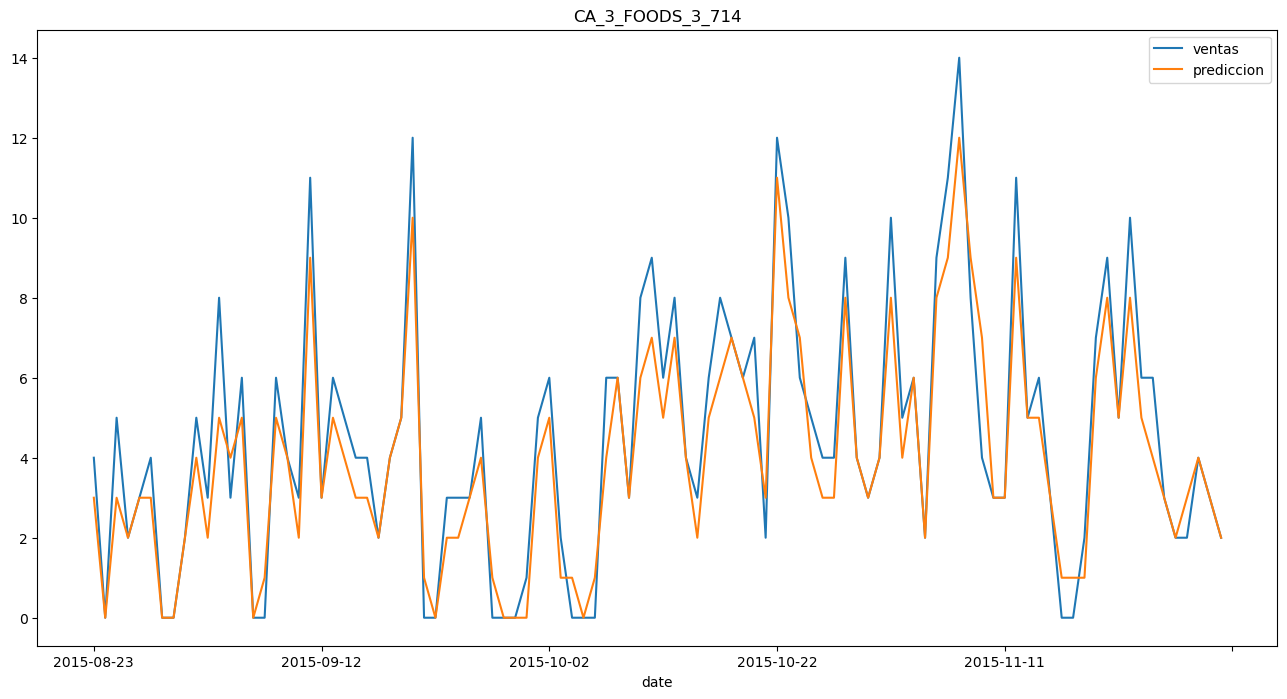

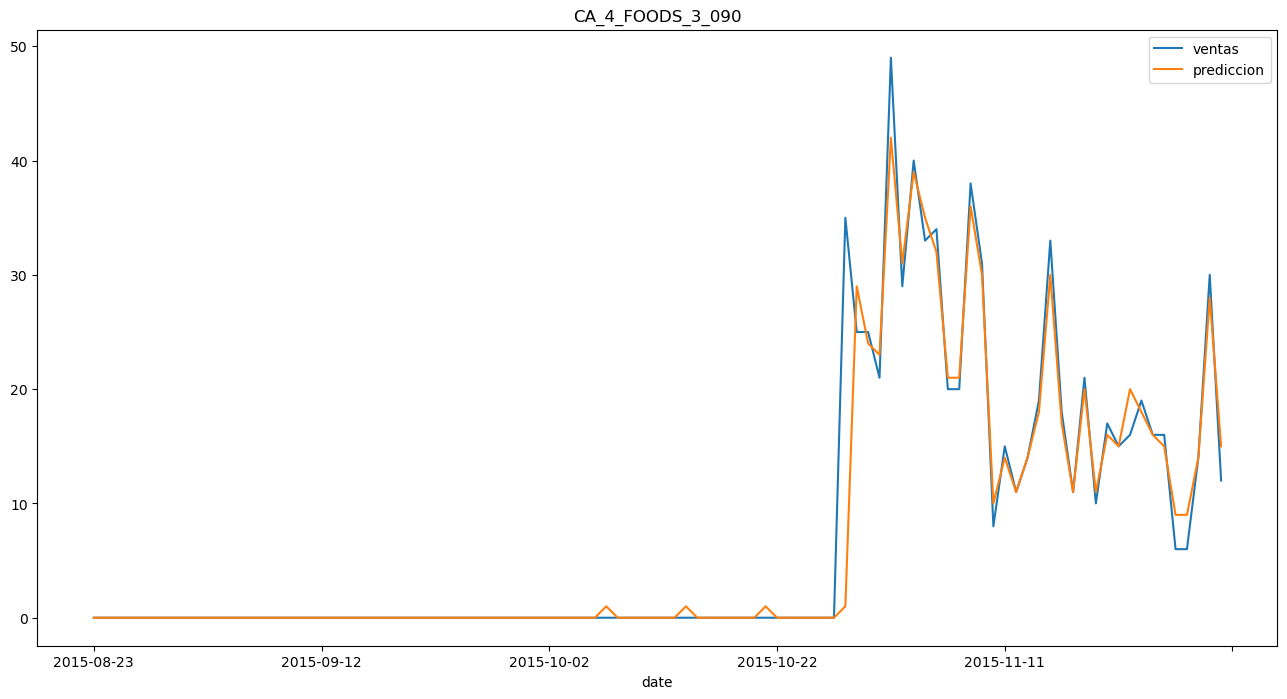

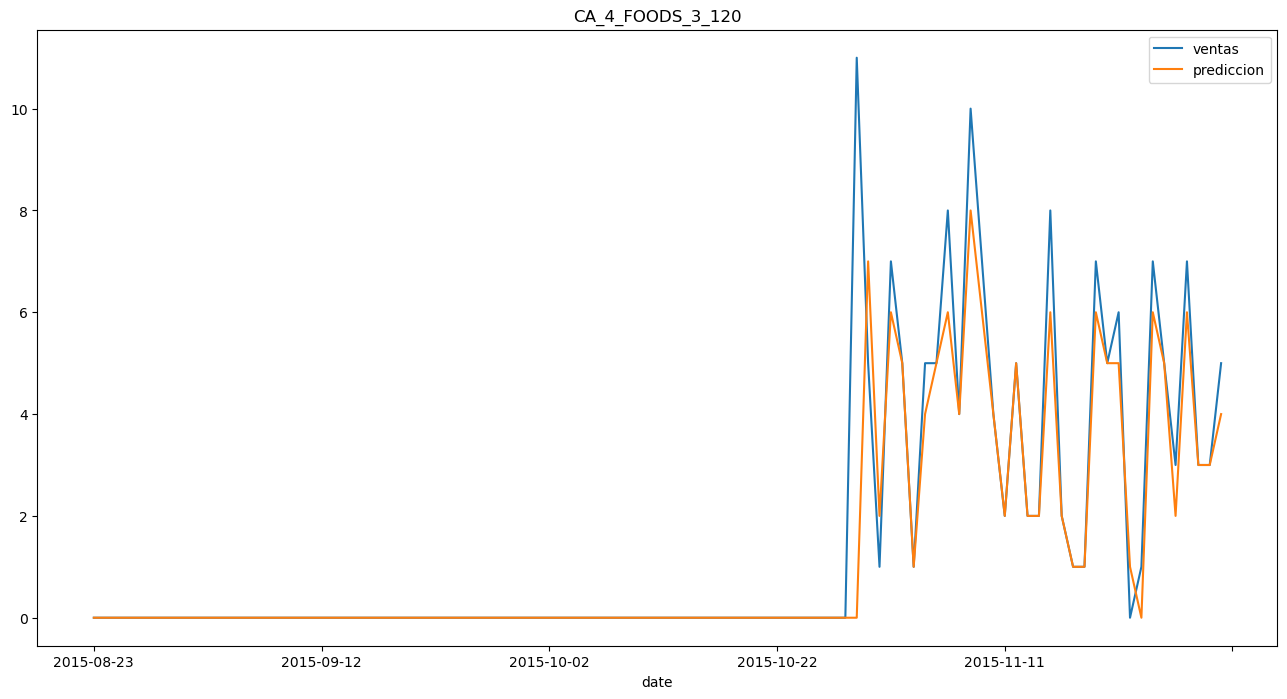

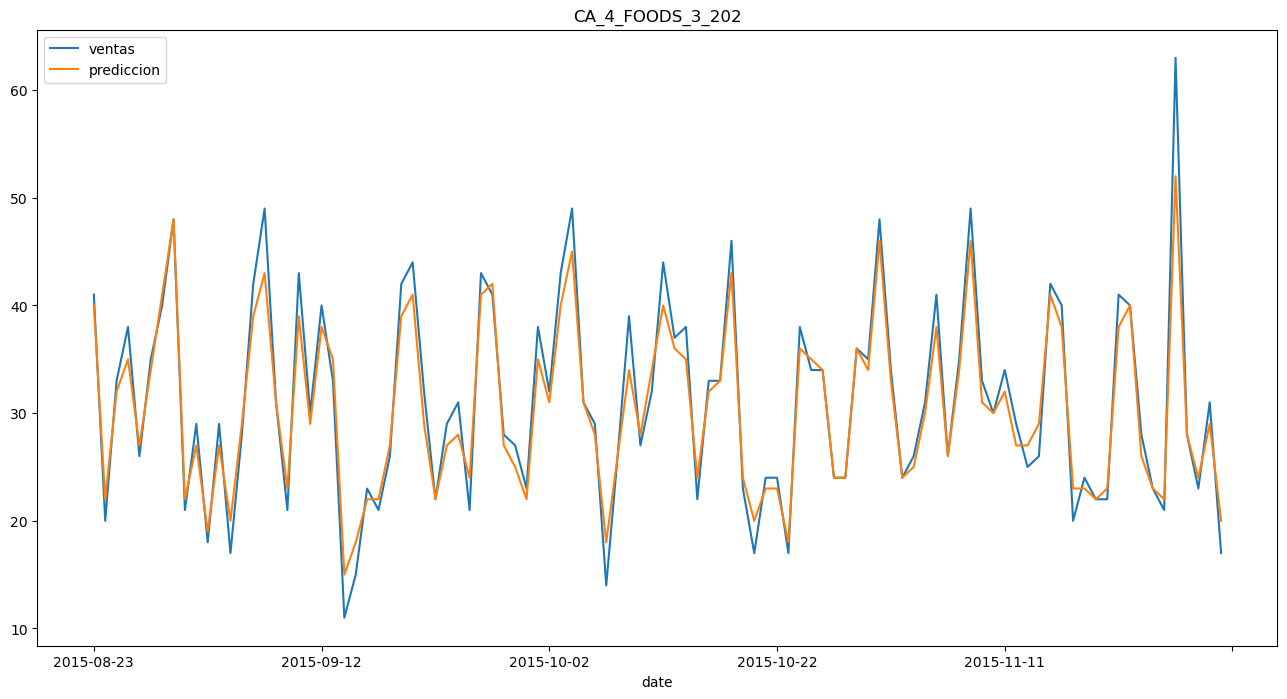

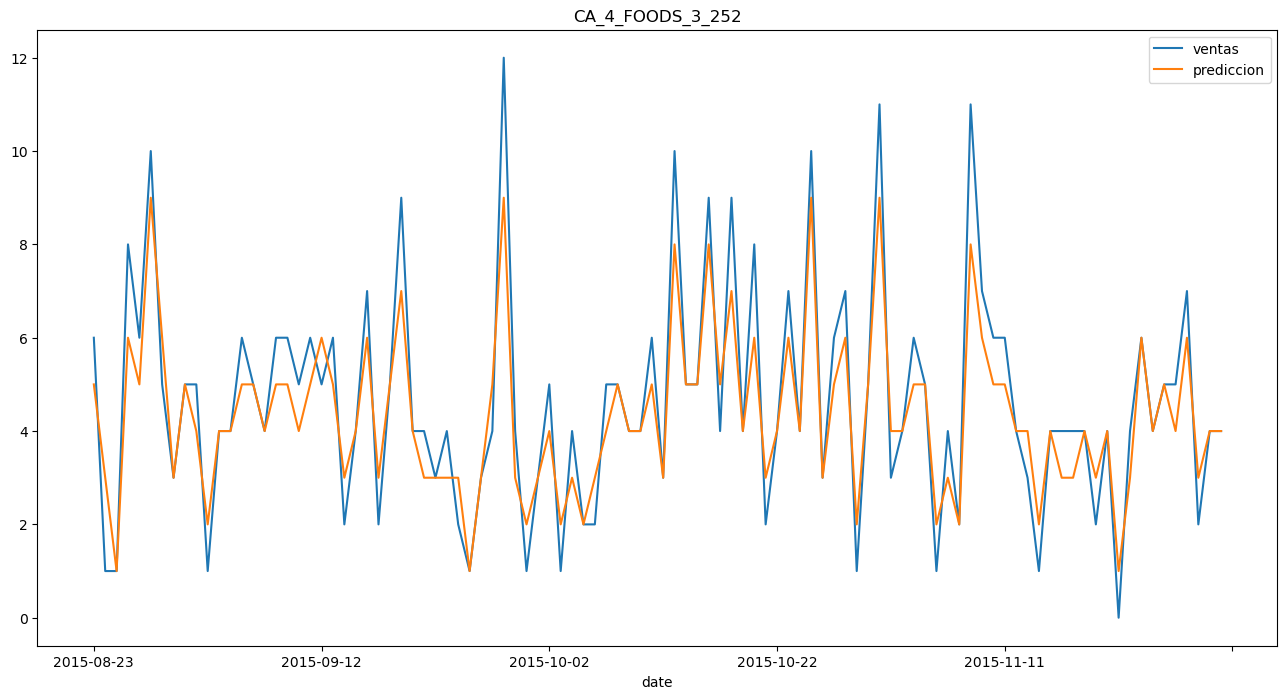

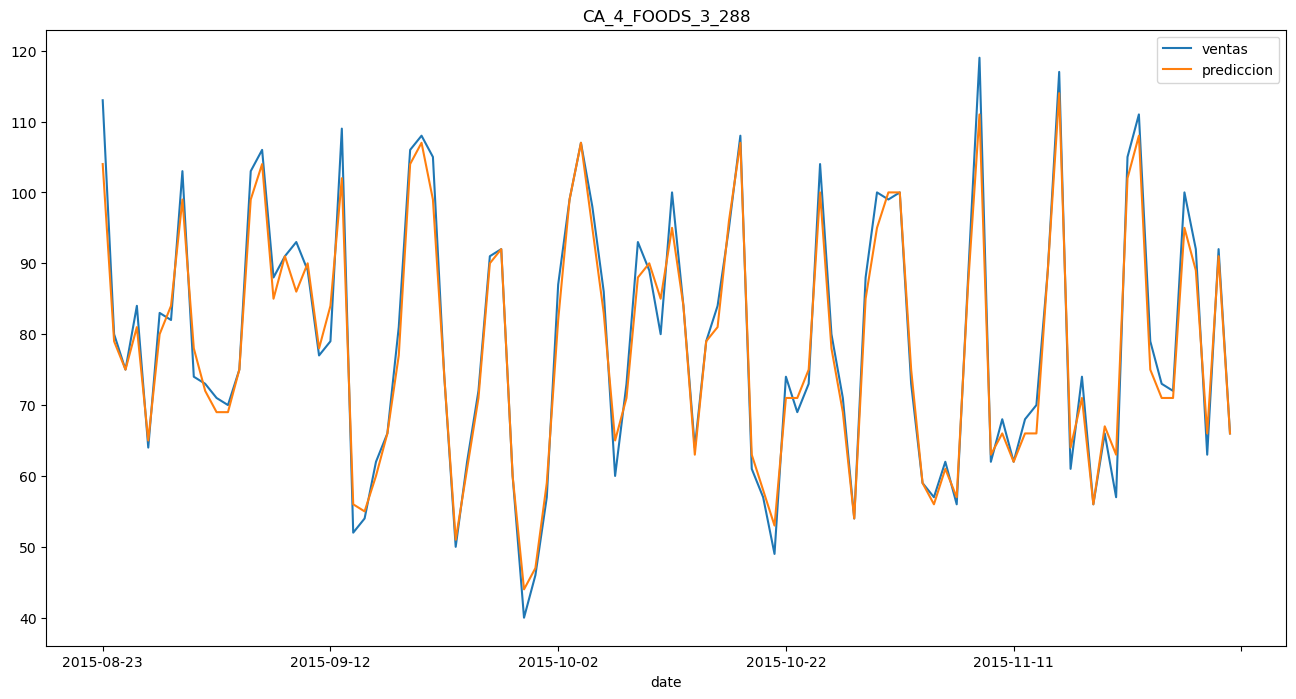

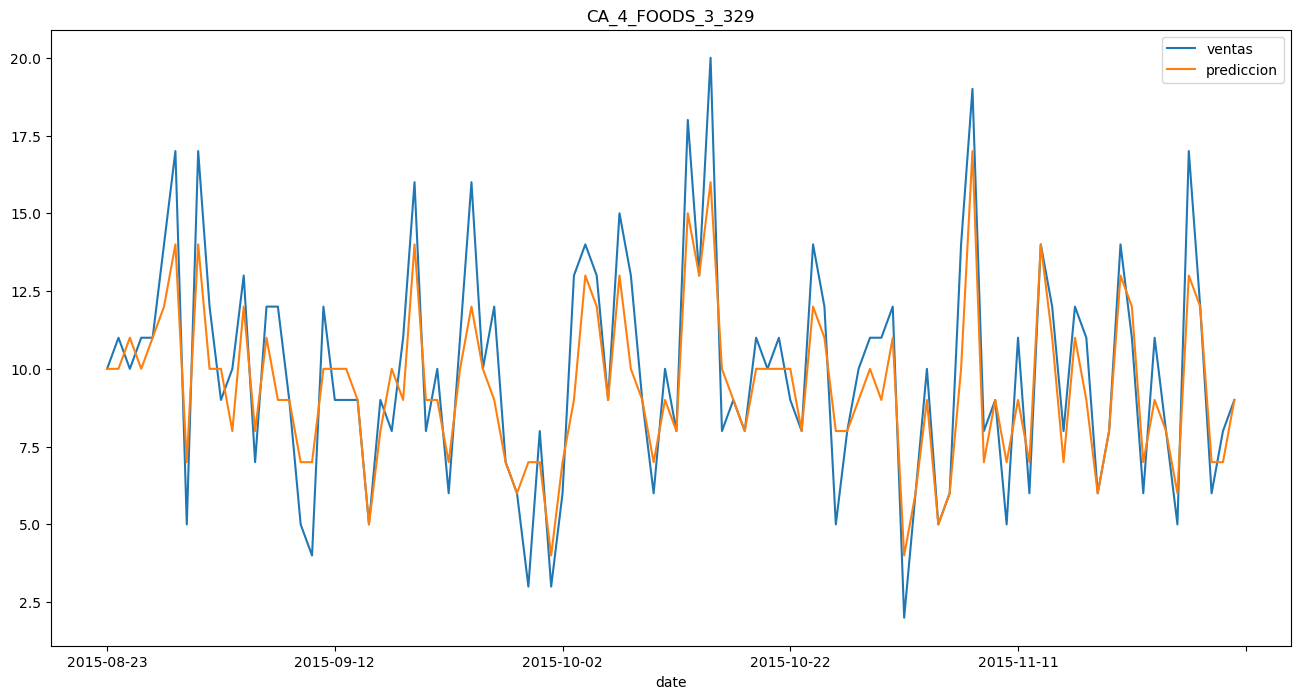

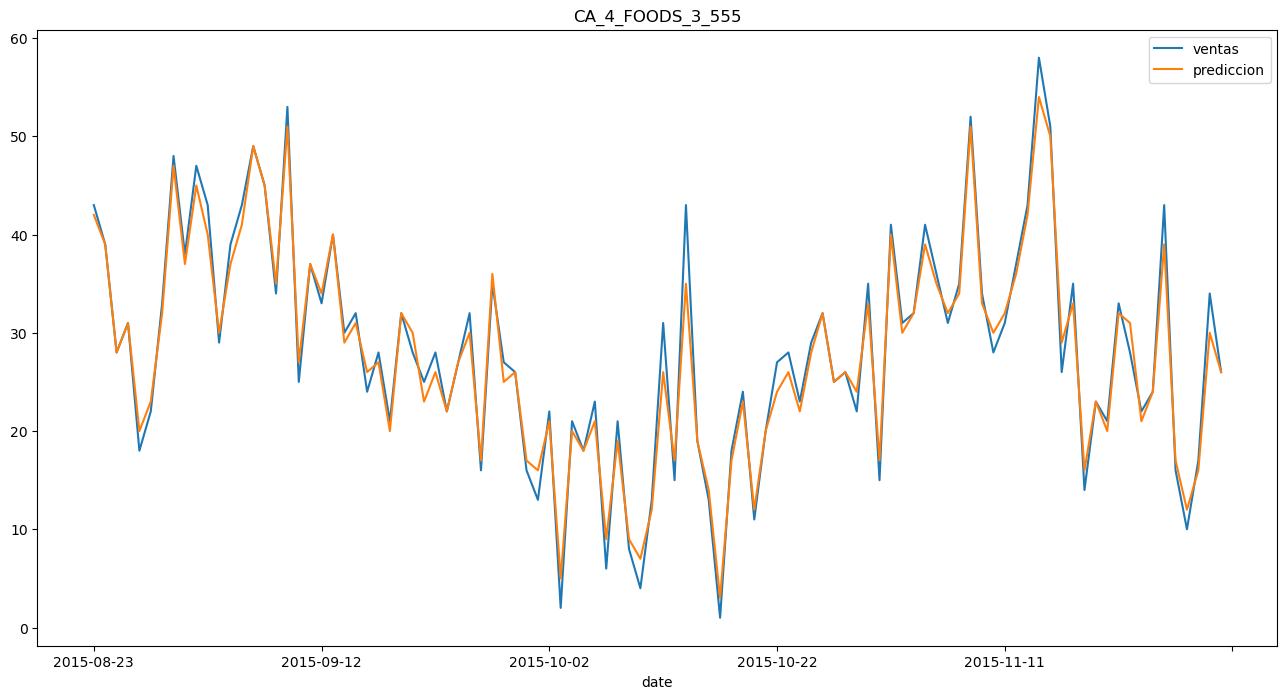

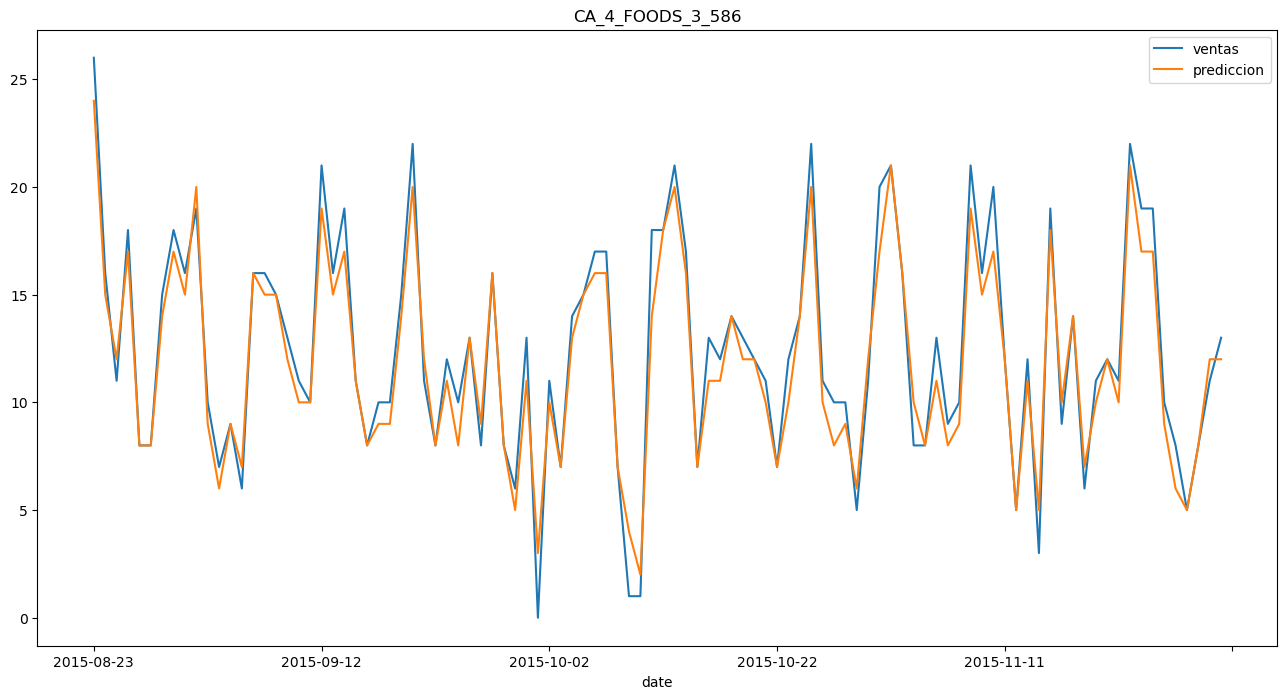

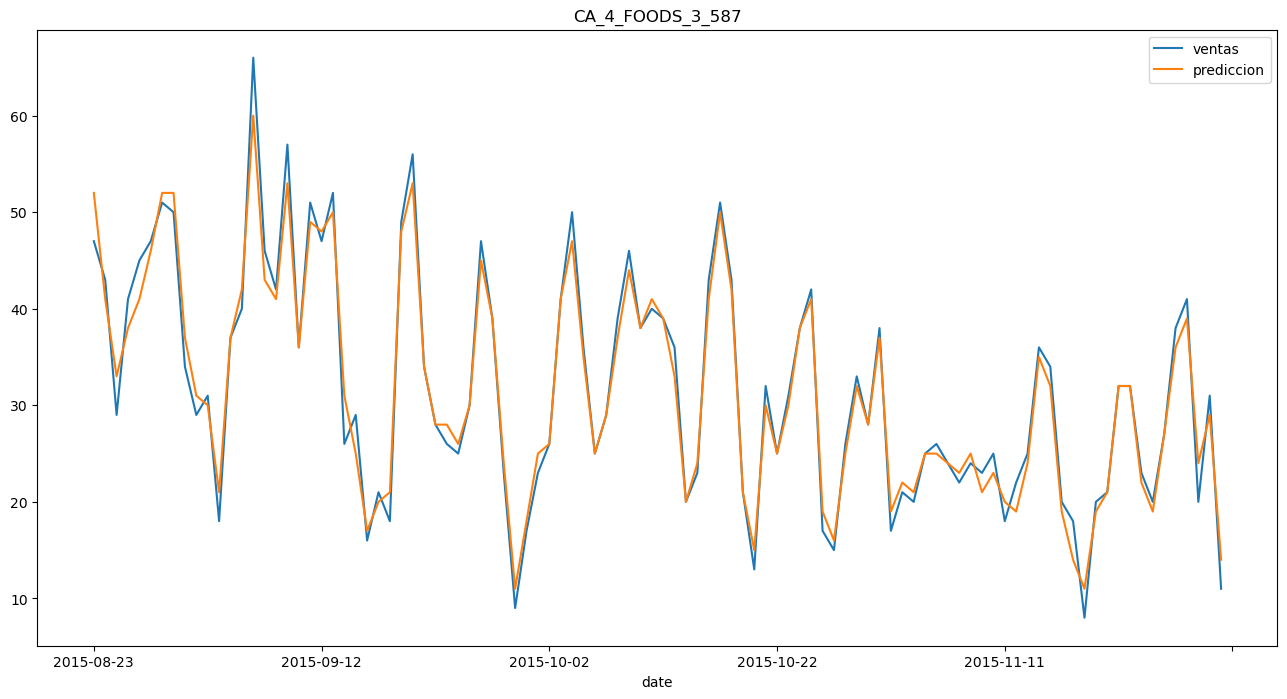

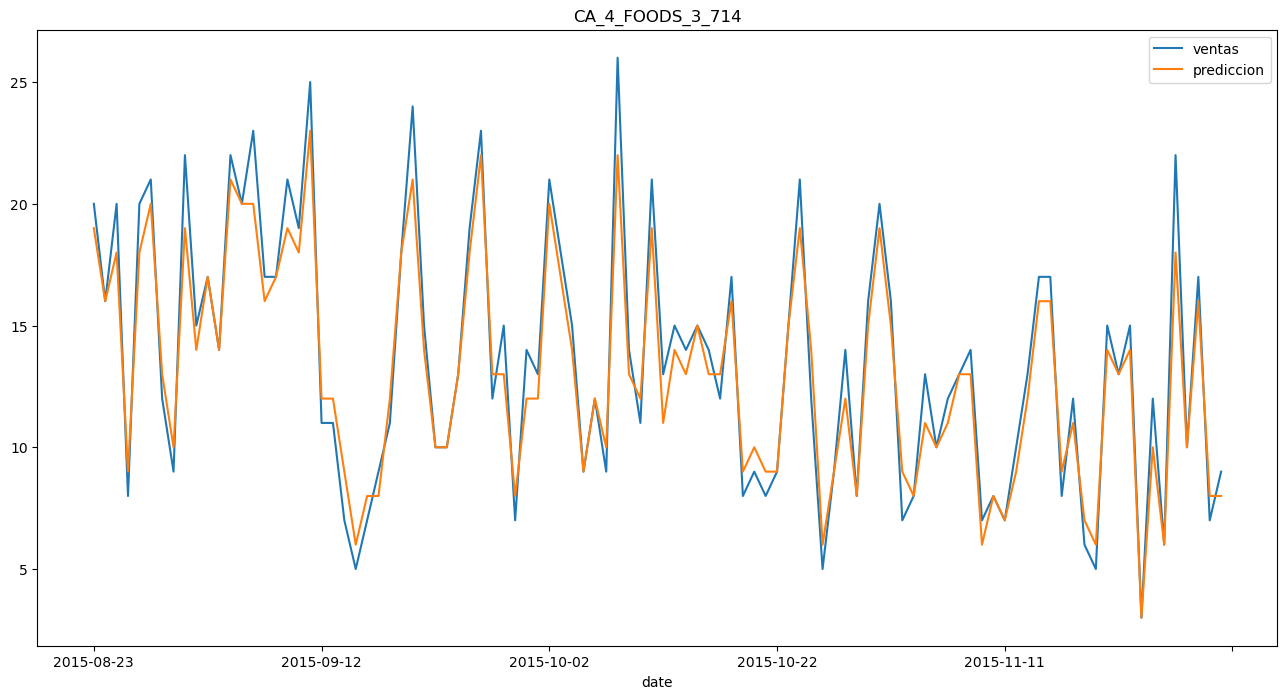

In [22]:
#unificar el df para poder extraer los x e y de cada producto
df =  pd.concat([x,y],axis=1)

for cada in range(0,len(lista_modelos)):
    
    #Prepara los datos necesarios
    producto = lista_modelos[cada][0]
    modelo = lista_modelos[cada][1]
    variables = modelo[0].feature_names_in_
    target = 'ventas'

    x_prod = df.loc[df.producto == producto].drop(columns=target).copy()
    y_prod = df.loc[df.producto == producto,'ventas'].copy()

    date = x_prod.date.values
    
    #Genera graficos de predicho vs real
    predicciones = pd.DataFrame(data={'date': date,
                                      'producto': producto,
                                      'ventas': y_prod,
                                      'prediccion': modelo.predict(x_prod[variables])})

    predicciones['prediccion'] = predicciones.prediccion.astype('int')
    predicciones.set_index('date',inplace=True)

    predicciones.tail(100).plot(figsize = (16,8),title = producto);